# Observables for MCMC

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lldddv2/relatipy/blob/main/docs/tutorials/06-mcmc-observables.ipynb)

This tutorial shows how `KerrMcmcModel.get_ra_dec_vr` predicts sky offsets and
line-of-sight velocities of a star orbiting a Kerr black hole, and how to wrap it in
a log-likelihood that a sampler such as `emcee` can call.

In [ ]:
%pip install -Uq relatipy emcee

In [1]:
import time

import emcee
import numpy as np
from astropy import units as u

import relatipy as rp

## 1. Why a dedicated model

`KerrMcmcModel` evaluates the observables of one proposal without creating public
`Kerr`, `Orbit` or `Solution` objects: the native evaluator receives the complete
proposal, integrates a timelike Kerr geodesic and returns all requested observables.
The observation model uses a small-angle sky projection and straight-line light
travel with the Rømer delay. It does not trace photons and does not include the
Shapiro delay or gravitational lensing.

## 2. The general API: `get_ra_dec_vr`

Construct an empty model and pass four keyword arguments:

- `kerr`: `mass` (a positive mass quantity), `spin` (dimensionless, in $[0, 1]$) and
  `vec`, the spin direction as three components in observer axes
  $(\mathrm{Dec}, \mathrm{RA}, \mathrm{away})$. `vec` is normalized; a zero vector is
  valid only for zero spin.
- `orbit`: the same one-family initial conditions as `Kerr.orbit`, plus optional
  physical time origins `t` and `tau`. Classical elements, Cartesian and spherical
  inputs use observer axes.
- `sol`: exactly one nonempty one-dimensional time quantity, `t_eval` (coordinate
  time), `tau_eval` (proper time) or `t_obs` (arrival time at the observer), plus
  optional solver settings `method`, `rtol`, `atol` and `max_steps`.
- `distance`: a positive observer distance quantity.

We use a star on a $1000\,\mathrm{au}$ orbit around a $4\times10^6\,M_\odot$ black
hole at $8\,\mathrm{kpc}$. The coordinate-time origin `t` places the initial state
(here the osculating periapsis, since the true anomaly `f` defaults to zero) at the
epoch 2000 yr, and we request observed arrival times with `t_obs` on the same clock.

In [2]:
model = rp.KerrMcmcModel()

kerr = {"mass": 4e6 * u.M_sun, "spin": 0.4, "vec": (0.0, 0.0, 1.0)}
orbit = {
    "a": 1000 * u.au,
    "e": 0.5,
    "inc": 0.6 * u.rad,
    "Omega": 0.4 * u.rad,
    "omega": 0.3 * u.rad,
    "t": 2000 * u.yr,
}
distance = 8 * u.kpc

t_model = np.linspace(2000.0, 2016.0, 300) * u.yr
start = time.perf_counter()
alpha, delta, v_los = model.get_ra_dec_vr(
    kerr=kerr, orbit=orbit, sol={"t_obs": t_model}, distance=distance,
)
print(f"one evaluation of {t_model.size} epochs: {1e3 * (time.perf_counter() - start):.1f} ms")
print("type:", type(alpha).__name__)
print("shape:", alpha.shape)
print("dtype:", alpha.dtype)
print("writeable:", alpha.flags.writeable)
print("alpha [arcsec]:", alpha[:3])
print("delta [arcsec]:", delta[:3])
print("v_los [km/s]:  ", v_los[:3])

one evaluation of 300 epochs: 5.4 ms
type: ndarray
shape: (300,)
dtype: float64
writeable: False
alpha [arcsec]: [0.03722321 0.03995567 0.04254601]
delta [arcsec]: [0.04912423 0.04639108 0.04349226]
v_los [km/s]:   [1802.33724665 1772.7596529  1737.09831495]


The three results are read-only NumPy arrays (not Astropy quantities) with one entry
per requested time, in the input order:

- `alpha` and `delta` are angular **offsets** in arcsec, not absolute right ascension
  and declination. Observer-frame $Y$ maps to `alpha` and $X$ maps to `delta`;
  positive $Z$ points away from the observer.
- `v_los` is a redshift-equivalent velocity in km/s, not the star's coordinate
  velocity along the line of sight.

Without an override, the general evaluator uses `method="dop853"`, `rtol=1e-9`,
`atol=1e-12` and `max_steps=100000`. These tolerances apply to the internal geometric
state, so check the convergence of the *observables* for your own fit, for example by
tightening the tolerances and comparing:

In [3]:
alpha_t, delta_t, v_los_t = model.get_ra_dec_vr(
    kerr=kerr, orbit=orbit, sol={"t_obs": t_model, "rtol": 1e-11, "atol": 1e-14},
    distance=distance,
)
print("max |d alpha| =", np.max(np.abs(alpha_t - alpha)) * 1e3, "mas")
print("max |d v_los| =", np.max(np.abs(v_los_t - v_los)), "km/s")

max |d alpha| = 4.217329610534115e-12 mas
max |d v_los| = 1.031821739161387e-09 km/s


## 3. Synthetic data

We draw 20 astrometric and 12 spectroscopic epochs from the model and add Gaussian
noise of $0.5\,\mathrm{mas}$ per sky coordinate and $10\,\mathrm{km\,s^{-1}}$ in
velocity. These values are arbitrary choices for this example. Note that the two
series may have different epochs.

In [4]:
rng = np.random.default_rng(42)

t_astro = np.sort(rng.uniform(2000.0, 2016.0, 20)) * u.yr
t_spec = np.sort(rng.uniform(2000.0, 2016.0, 12)) * u.yr
sigma_pos = 0.5e-3  # arcsec
sigma_v = 10.0      # km/s

a_true, d_true, _ = model.get_ra_dec_vr(
    kerr=kerr, orbit=orbit, sol={"t_obs": t_astro}, distance=distance)
_, _, v_true = model.get_ra_dec_vr(
    kerr=kerr, orbit=orbit, sol={"t_obs": t_spec}, distance=distance)

alpha_obs = a_true + rng.normal(0.0, sigma_pos, a_true.size)
delta_obs = d_true + rng.normal(0.0, sigma_pos, d_true.size)
v_obs = v_true + rng.normal(0.0, sigma_v, v_true.size)

`relatipy.plotting.plot_observables` plots data against a model. Its sky offsets
and errors are in mas, so we convert from arcsec. RA grows to the east, so it
increases to the left on the sky panel.

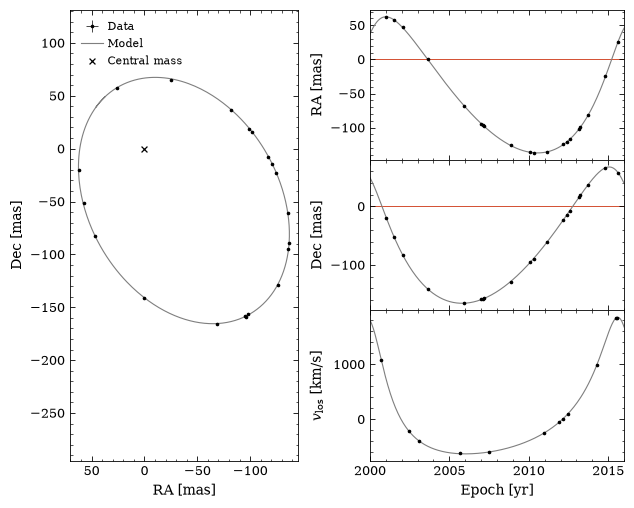

In [5]:

to_mas = 1e3
fig, (sky, ra_panel, dec_panel, v_panel) = rp.plotting.plot_observables(
    astrometry_epochs=t_astro, ra=alpha_obs * to_mas, ra_err=np.full(20, sigma_pos * to_mas),
    dec=delta_obs * to_mas, dec_err=np.full(20, sigma_pos * to_mas),
    spectroscopy_epochs=t_spec, velocity=v_obs, velocity_err=np.full(12, sigma_v),
    model_epochs=t_model, model_ra=alpha * to_mas, model_dec=delta * to_mas,
    model_velocity=v_los,
)

## 4. A custom log-likelihood

The model does not impose a likelihood. We fit three parameters, the mass in units of
$10^6\,M_\odot$, the eccentricity $e$ and the argument of periapsis $\omega$, and keep
everything else fixed at the true values. The log-likelihood is Gaussian with the
known noise levels, and the priors are uniform inside simple bounds. Proposals that
the model rejects (`ValueError`) or cannot integrate (`IntegrationError`) get
$-\infty$.

In [6]:
def predict(theta, sol):
    mass6, e, omega = theta
    return model.get_ra_dec_vr(
        kerr={**kerr, "mass": mass6 * 1e6 * u.M_sun},
        orbit={**orbit, "e": e, "omega": omega * u.rad},
        sol=sol,
        distance=distance,
    )


def log_prior(theta):
    mass6, e, omega = theta
    if 1.0 < mass6 < 10.0 and 0.0 <= e < 0.95 and -np.pi < omega < np.pi:
        return 0.0
    return -np.inf


def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    try:
        a_mod, d_mod, _ = predict(theta, {"t_obs": t_astro})
        _, _, v_mod = predict(theta, {"t_obs": t_spec})
    except (ValueError, rp.IntegrationError):
        return -np.inf
    chi2 = (np.sum(((alpha_obs - a_mod) / sigma_pos) ** 2)
            + np.sum(((delta_obs - d_mod) / sigma_pos) ** 2)
            + np.sum(((v_obs - v_mod) / sigma_v) ** 2))
    return lp - 0.5 * chi2


theta_true = np.array([4.0, 0.5, 0.3])
print("log p(true) =", log_probability(theta_true))
print("log p(off)  =", log_probability(np.array([4.2, 0.48, 0.32])))

log p(true) = -13.046976694146677
log p(off)  = -12246.734911634641


## 5. A very short `emcee` run

The likelihood is a plain Python function, so it plugs directly into
`emcee.EnsembleSampler`. To keep this notebook fast, we use only 12 walkers and 150
steps, and start the walkers in a small ball around the true values.

**This is a demonstration of the interface, not an inference.**

- The chain is far too short to be converged.
- The start is placed at the truth.
- No convergence diagnostics are applied.

The samples below must not be read as a posterior.

In [7]:
ndim, nwalkers, nsteps = 3, 12, 150
p0 = theta_true + np.array([0.02, 0.002, 0.002]) * rng.standard_normal((nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
start = time.perf_counter()
sampler.run_mcmc(p0, nsteps, progress=False)
print(f"{nwalkers * nsteps} proposals in {time.perf_counter() - start:.1f} s")
print("mean acceptance fraction:", np.mean(sampler.acceptance_fraction).round(2))

1800 proposals in 2.4 s
mean acceptance fraction: 0.63


The chain has shape `(steps, walkers, parameters)`. A quick summary of the last
step shows where the walkers are; with so few steps they have not explored the
distribution.

In [8]:
labels = [r"$M$ [$10^6\,M_\odot$]", r"$e$", r"$\omega$ [rad]"]
chain = sampler.get_chain()  # shape (nsteps, nwalkers, ndim)
print("chain shape:", chain.shape)
for name, true, last in zip(("M [1e6 Msun]", "e", "omega [rad]"), theta_true, chain[-1].T):
    print(f"{name:13s} true = {true:.4f}   last step: {last.mean():.4f} ± {last.std():.4f}")

chain shape: (150, 12, 3)
M [1e6 Msun]  true = 4.0000   last step: 4.0020 ± 0.0024
e             true = 0.5000   last step: 0.5000 ± 0.0005
omega [rad]   true = 0.3000   last step: 0.3000 ± 0.0010


`relatipy.plotting.plot_corner` draws a lower-triangle corner plot from samples of
shape `(n, k)` already in display units, with one label (including its unit) per
parameter. Here we discard the first 50 steps and flatten the walkers. Again, this is
only a demonstration of the plotting interface for a non-converged chain.

samples: (1200, 3)


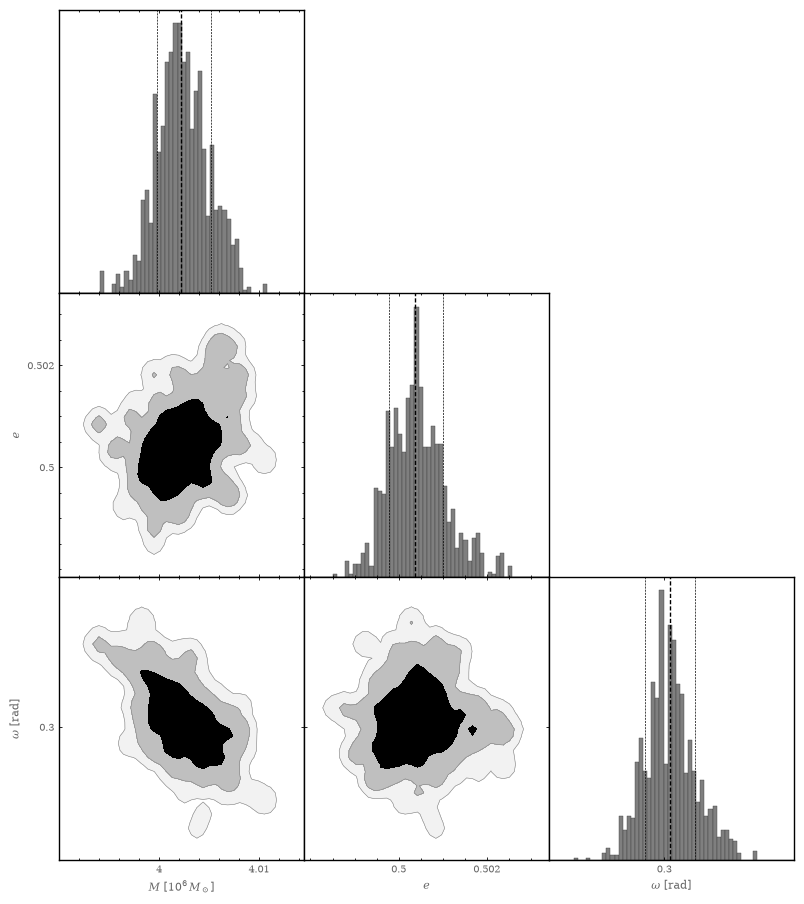

In [9]:

samples = sampler.get_chain(discard=50, flat=True)
print("samples:", samples.shape)
fig, axes = rp.plotting.plot_corner(samples, labels)

## 6. Legacy fixed-epoch API

`KerrMcmcModel` also keeps a fixed-epoch API:

- pass astrometric and spectroscopic epochs in Julian years and a
  `reference_epoch` to the constructor;
- configure the solver with `set_solver`;
- call the model with a numeric vector of exactly 13 values.

The vector is
`(D, M, t_p, a, e, inc, Omega, omega, xS0, yS0, vxS0, vyS0, v_LSR)`, in kpc, million
solar masses, Julian years, arcsec, dimensionless, radians (three angles), arcsec (two
offsets), arcsec/year (two drifts) and km/s. A constructor `spin_vector` in observer
axes supplies the default spin; a call-time `spin_vector` overrides it for one
proposal. The general API above is the more flexible interface.

In [10]:
legacy = rp.KerrMcmcModel([2002.33, 2003.0], [2002.33], reference_epoch=2000.0)
legacy.set_solver(method="dop853", rtol=1e-8, atol=1e-10)
params = np.array([
    8.33, 4.35, 2002.33, 0.1255, 0.8839,
    np.deg2rad(134.18), np.deg2rad(226.94), np.deg2rad(65.51),
    0.001, -0.002, 0.0001, -0.0002, 12.0,
])
alpha_l, delta_l, v_los_l = legacy(params, spin_vector=(0.0, 0.0, 0.5))
print("alpha [arcsec]:", alpha_l)
print("delta [arcsec]:", delta_l)
print("v_los [km/s]:  ", v_los_l)

alpha [arcsec]: [0.00291912 0.03839458]
delta [arcsec]: [-0.01344076  0.0506342 ]
v_los [km/s]:   [2541.24768882]


The returned `alpha` and `delta` have the length of the astrometric epochs and
`v_los` the length of the spectroscopic epochs. In this API, the periapsis state uses
an osculating Kepler convention, so `a` and `e` are not exact Kerr turning-point
parameters when the spin is nonzero.

## Next steps

- {doc}`../user-guide/kerr-mcmc`: the full description of inputs, units and limits.
- {doc}`../reference/observables`: the `KerrMcmcModel` API reference.
- [Plotting](05-plotting.ipynb): orbit previews and solution figures.